# Модель STRDP синаптической пластичности


## 0. Реализация модели

Подключение библиотек:

In [75]:
import numpy as np
from matplotlib import pyplot as plt

Модель LIF нейрона:

In [71]:
class LIF_neuron:
    def __init__(self, type, tau_m=20.0, v_rest=-65.0, v_thresh=-10.0, v_reset=-65.0, r_m=1.0, dt=1.0):
        self.type = type
        
        self.tau_m = tau_m
        self.v_rest = v_rest
        self.v_thresh = v_thresh
        self.v_reset = v_reset
        self.r_m = r_m
        self.dt = dt

        # current state
        self.v = v_rest
        self.I = 0.0
        self.spike = False

        # saving results
        self.trace_v = []

    # update state on dt + refactoring period
    def update(self, I_inj=0.0):
        self.I = I_inj

        #else
        dv = (-(self.v - self.v_rest) + self.r_m * self.I) * (self.dt / self.tau_m)

        self.v += dv

        # spike generation
        self.spike = False
        if self.v >= self.v_thresh:
            self.spike = True
            self.v = self.v_reset
        
        # saving voltage
        self.trace_v.append(self.v)
        
    def get_voltage(self):
        return self.v

    def has_spiked(self):
        return self.spike


Модель синапса с STRDP-правилом:

In [ ]:
class STRDP_Synapse:
    def __init__(self, pre_neuron, post_neuron, weight=1.0, tau_s=5.0,
                A_plus=0.015, A_minus=0.01, tau_plus=7.0, tau_minus=5.0,
                w_max=1.0, w_min=0.0):
        self.pre = pre_neuron
        self.post = post_neuron
        self.weight = weight
        self.tau_s = tau_s
        self.mu = 0.0005

        self.I_syn = 0.0

        self.A_plus = A_plus
        self.A_minus = A_minus
        self.tau_plus = tau_plus
        self.tau_minus = tau_minus
        self.w_max = w_max
        self.w_min = w_min

        # trace
        self.trace_pre = 0.0
        self.trace_post = 0.0

        # history for graphics
        self.weight_history = [weight]
        self.trace_pre_history = []
        self.trace_post_history = []

        self.dt = self.pre.dt

        # for the method from article
        self.nu = 0.1
        self.alpha = 0.3
        self.b_minus = 20.0

        # last spikes
        self.last_pre_spike = -1e6
        self.last_post_spike = -1e6

    def strdp_method(self, t):
        spike_pre = self.pre.has_spiked()
        spike_post = self.post.has_spiked()

        if spike_pre:
            # if exists post before pre
            if self.last_post_spike != -1e6 and self.last_post_spike < t:
                dt = t - self.last_post_spike
                # LTD
                F_minus = self.nu * self.alpha * self.weight
                ltd = F_minus / (1 + np.exp(self.b_minus - dt / self.tau_minus))
                self.weight -= ltd * self.dt

            self.last_pre_spike = t

        if spike_post:
            # if exists pre before post
            if self.last_pre_spike != -1e6 and self.last_pre_spike < t:
                dt = t - self.last_pre_spike
                # LTP
                F_plus = self.nu * (self.w_max - self.weight)
                ltp = F_plus * np.exp(-dt / self.tau_plus)

                F_minus = self.nu * self.alpha * self.weight
                ltd = F_minus / (1 + np.exp(self.b_minus - dt / self.tau_minus))

                self.weight += (ltp - ltd) * self.dt

            self.last_post_spike = t

        self.weight = np.clip(self.weight, self.w_min, self.w_max)
        self.weight_history.append(self.weight)

    def update(self, t):
        # if new spike from pre
        # if self.pre.spike:
        #     total_spike_input = 500.0
        # else:
        #     total_spike_input = 0.0

        # update synaptic I
        # dI_syn = (-self.I_syn + total_spike_input) * (self.dt / self.tau_s)
        # self.I_syn += dI_syn

        self.strdp_method(t)

    def get_weight(self):
        return self.weight
    
    def get_current(self):
        return self.I_syn

Сеть для генерации эксперимента:

In [117]:
class Network:
    def __init__(self, Tmax, scale, n_pre, n_post, I_pre, I_post, weight_matrix):
        self.Tmax = Tmax
        self.scale = scale
        self.n_pre = n_pre
        self.n_post = n_post
        self.I_pre = I_pre
        self.I_post = I_post
        self.weight_matrix = weight_matrix

        # time
        self.T = np.linspace(0, Tmax, Tmax * scale)
        self.dt = self.T[1] - self.T[0]

        # neurons
        self.pre_neurons = np.array([LIF_neuron(type='pre', dt=self.dt) for _ in range(n_pre)], dtype=object)
        self.post_neurons = np.array([LIF_neuron(type='post', dt=self.dt) for _ in range(n_post)], dtype=object)

        # synapses
        self.synapses = np.empty((n_pre, n_post), dtype=object)
        for i in range(n_pre):
            for j in range(n_post):
                self.synapses[i, j] = STRDP_Synapse(
                    self.pre_neurons[i], 
                    self.post_neurons[j], 
                    weight=weight_matrix[i, j]
                )

        # data saving
        self.V_pre_history = np.zeros((len(self.T), n_pre))
        self.V_post_history = np.zeros((len(self.T), n_post))
        self.weights_history = np.zeros((len(self.T), n_pre, n_post))
        self.I_syn_history = np.zeros((len(self.T), n_post))

        self.pre_spikes_history = np.zeros((len(self.T), n_pre), dtype=bool)
        self.post_spikes_history = np.zeros((len(self.T), n_post), dtype=bool)


    def run_simulation(self):
        for step, t in enumerate(self.T):
            for i, neuron in enumerate(self.pre_neurons):
                neuron.update(I_inj=self.I_pre[i](t))
                self.V_pre_history[step, i] = neuron.get_voltage()
                self.pre_spikes_history[step, i] = neuron.has_spiked()

                for i in range(self.n_pre):
                    for j in range(self.n_post):
                        self.synapses[i, j].update(t)
                        self.weights_history[step, i, j] = self.synapses[i, j].get_weight()


            for j, neuron in enumerate(self.post_neurons):
                # update post
                neuron.update(I_inj=self.I_post[j](t))
                self.V_post_history[step, j] = neuron.get_voltage()
                self.post_spikes_history[step, j] = neuron.has_spiked()
                self.I_syn_history[step, j] = self.I_post[j](t)

    def get_results(self):
        return {
            'time': self.T,
            'V_pre': self.V_pre_history,
            'V_post': self.V_post_history,
            'weights': self.weights_history,
        #    'I_syn': self.I_syn_history,
            'pre_spikes': self.get_spike_trains(self.pre_neurons),
            'post_spikes': self.get_spike_trains(self.post_neurons)
        }

    def get_spike_trains(self, neurons):
        spike_trains = []
        for neuron_idx, neuron in enumerate(neurons):
            if neuron.type == 'pre':
                spike_times = self.T[self.pre_spikes_history[:, neuron_idx]]
            else:
                spike_times = self.T[self.post_spikes_history[:, neuron_idx]]
            spike_trains.append(spike_times)
        return spike_trains

    def get_final_weights(self):
        final_weights = np.zeros((self.n_pre, self.n_post))

        for i in range(self.n_pre):
            for j in range(self.n_post):
                final_weights[i, j] = self.synapses[i, j].get_weight()
        return final_weights

## 1. Эксперимент с различными частотами (проверка работы STRDP - обновления весов)

Частота на пресинаптическом больше чем на постсинапическом:

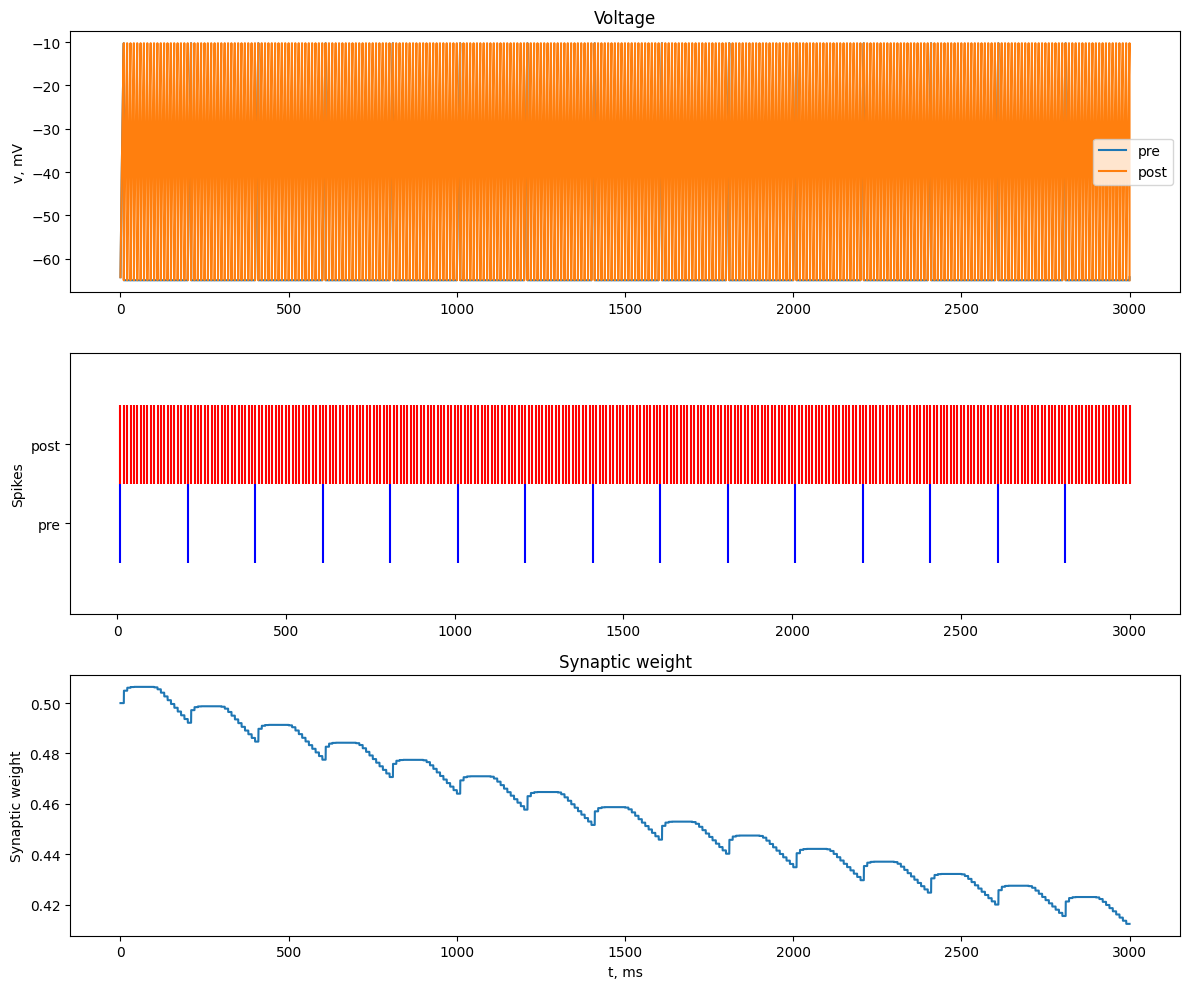

Initial weight: 0.5
Final weight: 0.41237325438357325
Difference: -0.0876
Presynaptic spikes: 15
Postsynaptic spikes: 300


In [118]:
Tmax = 3000
scale = 10
n_pre = 1
n_post = 1

def I_pre(t):
    return 140.0 if (t % 200.0) < 10.0 else 0.0

def I_post(t):
    return 140.0 if ((t - 10.0) % 10.0) < 10.0 else 0.0

weight_matrix = np.array([[0.5]])

I_pre_func = [I_pre]
I_post_func = [I_post]
network = Network(Tmax, scale, n_pre, n_post, I_pre_func, I_post_func, weight_matrix)

network.run_simulation()
results = network.get_results()


# visualising
plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(results['time'], results['V_pre'][:, 0], label='pre')
plt.plot(results['time'], results['V_post'][:, 0], label='post')
plt.ylabel('v, mV')
plt.legend()
plt.title('Voltage')

# spikes
plt.subplot(3, 1, 2)
pre_spike_times = results['pre_spikes'][0]
post_spike_times = results['post_spikes'][0]
plt.eventplot([pre_spike_times, post_spike_times], colors=['blue', 'red'])
plt.ylabel('Spikes')
plt.yticks([0, 1], ['pre', 'post'])

# synaptic weight
plt.subplot(3, 1, 3)
plt.plot(results['time'], results['weights'][:, 0, 0])
plt.ylabel('Synaptic weight')
plt.xlabel('t, ms')
plt.title('Synaptic weight')

plt.tight_layout()
plt.show()

# results
final_weight = network.get_final_weights()[0, 0]
print(f"Initial weight: {weight_matrix[0, 0]}")
print(f"Final weight: {final_weight}")
print(f"Difference: {final_weight - weight_matrix[0, 0]:.4f}")

# spikes
pre_spike_count = len(results['pre_spikes'][0])
post_spike_count = len(results['post_spikes'][0])
print(f"Presynaptic spikes: {pre_spike_count}")
print(f"Postsynaptic spikes: {post_spike_count}")

Частота на постсинаптическом больше чем на пресинаптическом:

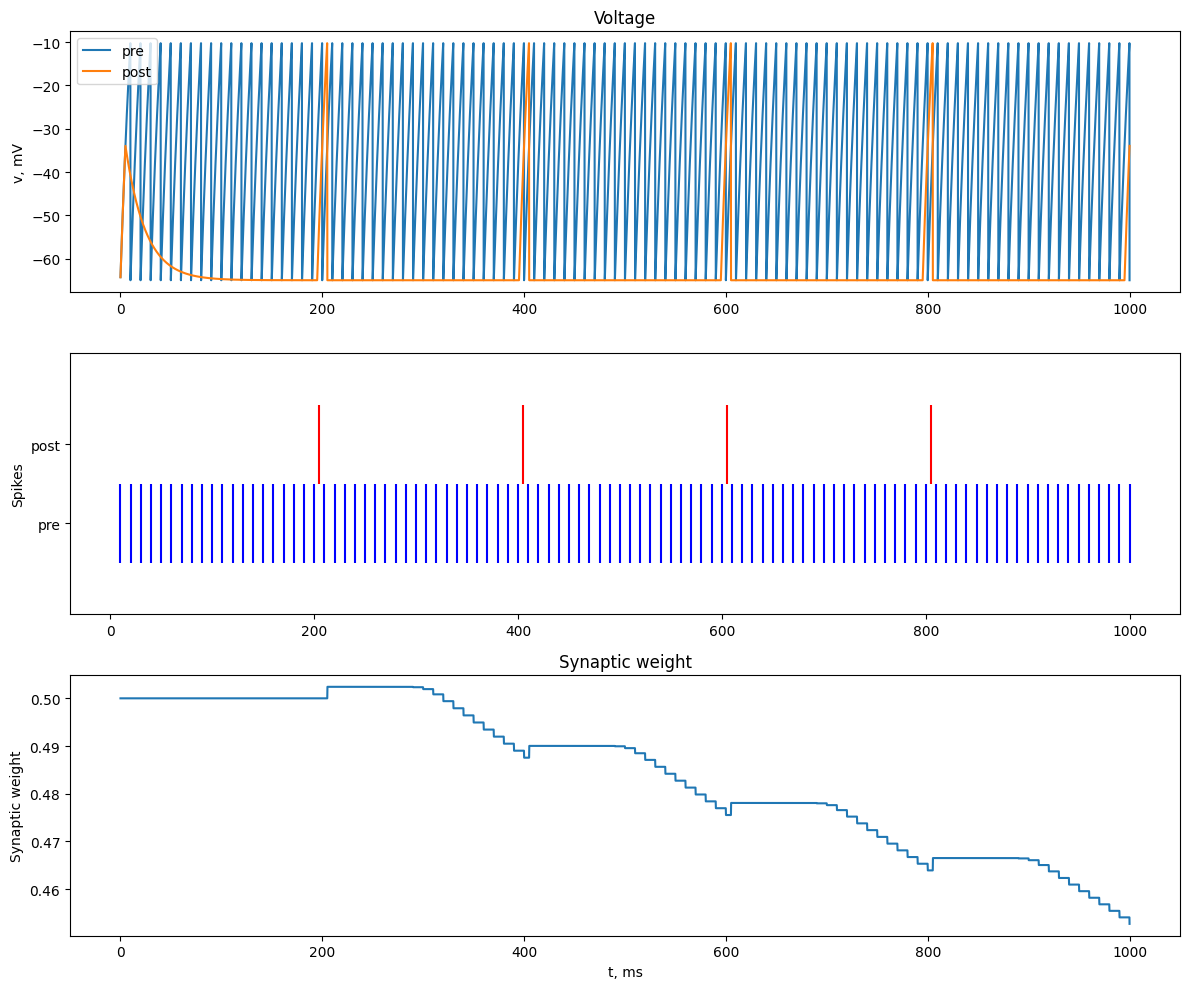

Initial weight: 0.5
Final weight: 0.4527211706414624
Difference: -0.0473
Presynaptic spikes: 100
Postsynaptic spikes: 4


In [119]:
Tmax = 1000
scale = 10
n_pre = 1
n_post = 1

def I_pre(t):
    return 140.0 if (t % 10.0) < 10.0 else 0.0

def I_post(t):
    return 140.0 if ((t + 5.0) % 200.0) < 10.0 else 0.0

weight_matrix = np.array([[0.5]])

I_pre_func = [I_pre]
I_post_func = [I_post]
network = Network(Tmax, scale, n_pre, n_post, I_pre_func, I_post_func, weight_matrix)

network.run_simulation()
results = network.get_results()


# visualising
plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(results['time'], results['V_pre'][:, 0], label='pre')
plt.plot(results['time'], results['V_post'][:, 0], label='post')
plt.ylabel('v, mV')
plt.legend()
plt.title('Voltage')

# spikes
plt.subplot(3, 1, 2)
pre_spike_times = results['pre_spikes'][0]
post_spike_times = results['post_spikes'][0]
plt.eventplot([pre_spike_times, post_spike_times], colors=['blue', 'red'])
plt.ylabel('Spikes')
plt.yticks([0, 1], ['pre', 'post'])

# synaptic weight
plt.subplot(3, 1, 3)
plt.plot(results['time'], results['weights'][:, 0, 0])
plt.ylabel('Synaptic weight')
plt.xlabel('t, ms')
plt.title('Synaptic weight')

plt.tight_layout()
plt.show()

# results
final_weight = network.get_final_weights()[0, 0]
print(f"Initial weight: {weight_matrix[0, 0]}")
print(f"Final weight: {final_weight}")
print(f"Difference: {final_weight - weight_matrix[0, 0]:.4f}")

# spikes
pre_spike_count = len(results['pre_spikes'][0])
post_spike_count = len(results['post_spikes'][0])
print(f"Presynaptic spikes: {pre_spike_count}")
print(f"Postsynaptic spikes: {post_spike_count}")